# 05 · Modelado P1 - YOLOv11

- **Proyecto:** Detección de Residuos Urbanos · Computer Vision · UNI 2026-I
- **Autor:** Jairzinho Santos

P1 es el motor de los experimentos comparativos del paper: la **matriz cross-domain 3×3**,
el contraste **oficial vs por-video** en RoLID (cuantificar la inflación por fuga), la
**ablación de resolución** (640 vs 1024) y la comparativa **A/B de vidrio**. Corre bien en
la Mac: Ultralytics usa entrada de tamaño fijo, así que MPS compila sus kernels una sola
vez a diferencia de Faster R-CNN (P0), cuyas entradas variables lo hacían inviable aquí.

Misma mecánica que la 04: switch de hardware, registro DONE/FAILED con guardián por
experimento, guardián de presupuesto en horas, reanudación (nativa de Ultralytics vía
`last.pt`) y tablero de estado.

| ID | Experimento | Épocas (paciencia) | Est. Mac (MPS) |
|---|---|---|---|
| F1 | taco_1cls @640 | 150 (30) | 1–1.5 h |
| F2 | rolid_video @640 | 100 (25) | 3–5 h |
| F3 | rolid_oficial @640 | 100 (25) | 3–5 h |
| F4 | uav_1cls @640 | 150 (30) | ~0.5 h |
| G1 / G2 | taco_6cls / taco_5cls @640 | 150 (30) | ~1 h c/u |
| H1 | taco_1cls @1024 | 150 (30) | ~3 h |
| H2 | rolid_video @1024 | 100 (25) | 8–12 h |

**Toda la evaluación de test se hace contra los COCO GT de gold con pycocotools** la
misma fuente métrica que P0, para que las tablas del paper sean comparables entre familias.

## Parte 0 · Entorno

In [1]:
import sys, subprocess, importlib

def _asegurar(paquetes):
    faltan = []
    for p, m in paquetes:
        try:
            importlib.import_module(m)
        except ImportError:
            faltan.append(p)
    if faltan:
        print("instalando:", faltan)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + faltan, check=False)

_asegurar([("ultralytics", "ultralytics"), ("pycocotools", "pycocotools"),
           ("pandas", "pandas"), ("matplotlib", "matplotlib")])

import os, gc, json, time, math, shutil, datetime, traceback, collections, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
from IPython.display import display

EN_COLAB = "google.colab" in sys.modules
if torch.cuda.is_available():
    PERFIL, DEVICE = ("colab" if EN_COLAB else "cuda"), 0
elif torch.backends.mps.is_available():
    PERFIL, DEVICE = "mac", "mps"
else:
    PERFIL, DEVICE = "cpu", "cpu"

_cwd     = Path.cwd()
CODE_DIR = _cwd.parent if _cwd.name == "notebooks" else _cwd
GOLD     = CODE_DIR / "data" / "gold"
RUNS     = CODE_DIR / "experiments" / "p1"
FIG_DIR  = CODE_DIR / "reports" / "figuras_p1"
for d in (RUNS, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

RUTA_DRIVE_ZIP = "/content/drive/MyDrive/gold_colab_p1.zip"
if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    RUNS = Path("/content/drive/MyDrive/waste_p1_runs")
    RUNS.mkdir(parents=True, exist_ok=True)
    if not (GOLD / "yolo").exists():
        print("desempaquetando gold desde Drive...")
        GOLD.mkdir(parents=True, exist_ok=True)
        import zipfile
        with zipfile.ZipFile(RUTA_DRIVE_ZIP) as z:
            z.extractall(GOLD)

CFG_PERFIL = {
    "mac":   {"bs_640": 48, "bs_1024": 20, "workers": 8},
    "colab": {"bs_640": 64, "bs_1024": 28, "workers": 2},
    "cuda":  {"bs_640": 64, "bs_1024": 28, "workers": 4},
    "cpu":   {"bs_640": 8,  "bs_1024": 4,  "workers": 0},
}[PERFIL]

EJECUTAR = "todo"        # "todo" | lista de ids, p. ej. ["F1", "F4"]
FORZAR   = []
PRESUPUESTO_HORAS_EXP = 20.0
PRUEBA_RAPIDA = False

SEMILLA = 42
torch.manual_seed(SEMILLA); np.random.seed(SEMILLA); random.seed(SEMILLA)

_caf = None
if PERFIL == "mac" and shutil.which("caffeinate"):
    _caf = subprocess.Popen(["caffeinate", "-dims"])
    print("caffeinate activo (PID {})".format(_caf.pid))

print("perfil:", PERFIL, "· device:", DEVICE)
print("runs  :", RUNS)
assert (GOLD / "yolo").exists(), "gold/yolo no existe: ejecutar la notebook 03 primero"
if PRUEBA_RAPIDA:
    print("[ MODO PRUEBA RÁPIDA ]")

caffeinate activo (PID 33805)
perfil: mac · device: mps
runs  : /Volumes/JS-MAIN/Personal/Education/UNI/AI Master/Semesters & Class/Semester 3/Computer Vision/final-project/code/experiments/p1


## Parte 1 · Registro de experimentos

Idéntico contrato que la 04: guardián que nunca rompe la notebook, DONE/FAILED con
métricas o traceback, y tablero. La reanudación aquí es la nativa de Ultralytics: cada
experimento guarda `last.pt` por época y el reintento continúa desde ahí.

In [2]:
def dir_exp(exp_id):
    d = RUNS / exp_id
    d.mkdir(parents=True, exist_ok=True)
    return d


def estado_exp(exp_id):
    d = RUNS / exp_id
    if (d / "DONE.json").exists():
        return "DONE"
    if (d / "FAILED.json").exists():
        return "FAILED"
    log = d / "log.txt"
    if log.exists() and time.time() - log.stat().st_mtime < 300:
        return "RUNNING"
    if (d / "ultra" / "train" / "weights" / "last.pt").exists():
        return "PARCIAL"
    return "PENDING"


def registrar(exp_id, linea):
    with open(dir_exp(exp_id) / "log.txt", "a") as f:
        f.write("[{}] {}\n".format(datetime.datetime.now().isoformat(timespec="seconds"), linea))


def ejecutar(exp_id, fn, descripcion=""):
    if EJECUTAR != "todo" and exp_id not in EJECUTAR:
        print("[omitido] {} (no está en EJECUTAR)".format(exp_id)); return
    d = dir_exp(exp_id)
    if exp_id in FORZAR:
        for f_ in ("DONE.json", "FAILED.json", "metrics.json"):
            (d / f_).unlink(missing_ok=True)
        shutil.rmtree(d / "ultra", ignore_errors=True)
    if (d / "DONE.json").exists():
        print("[DONE ya] {} — se omite".format(exp_id)); return
    (d / "FAILED.json").unlink(missing_ok=True)
    print("\n" + "─" * 96)
    print("EXPERIMENTO {} · {}".format(exp_id, descripcion))
    print("─" * 96)
    registrar(exp_id, "inicio · perfil=" + PERFIL)
    t0 = time.time()
    try:
        metricas = fn(exp_id) or {}
        metricas["tiempo_s"] = round(time.time() - t0, 1)
        metricas["dispositivo"] = str(DEVICE)
        (d / "DONE.json").write_text(json.dumps(
            {"exp": exp_id, "terminado": datetime.datetime.now().isoformat(timespec="seconds"),
             **metricas}, indent=2, ensure_ascii=False, default=float))
        registrar(exp_id, "DONE en {:.0f}s".format(time.time() - t0))
        print("[DONE] {} en {:.0f} min".format(exp_id, (time.time() - t0) / 60))
    except KeyboardInterrupt:
        registrar(exp_id, "interrumpido — last.pt permite reanudar")
        raise
    except Exception as e:
        tb = traceback.format_exc()
        (d / "FAILED.json").write_text(json.dumps(
            {"exp": exp_id, "error": str(e)[:500], "traceback": tb,
             "cuando": datetime.datetime.now().isoformat(timespec="seconds")}, indent=2))
        registrar(exp_id, "FAILED: " + str(e)[:200])
        print("[FALLÓ] {} — {}: {}".format(exp_id, type(e).__name__, str(e)[:200]))
        print("        la notebook continúa con el siguiente experimento")
    finally:
        gc.collect()
        if DEVICE == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass
        elif DEVICE == 0:
            torch.cuda.empty_cache()


PLAN = ["F1", "F4", "G1", "G2", "H1", "F2", "F3", "H2"]   # barato -> caro


def tablero():
    filas = []
    for e in PLAN:
        est = estado_exp(e)
        extra = ""
        d = RUNS / e
        if est == "DONE":
            m = json.loads((d / "DONE.json").read_text())
            extra = "val_AP50={:.3f}  {:.0f} min".format(
                m.get("mejor", {}).get("val_ap50", float("nan")),
                m.get("tiempo_s", 0) / 60)
        elif est == "FAILED":
            extra = json.loads((d / "FAILED.json").read_text())["error"][:60]
        filas.append({"exp": e, "estado": est, "detalle": extra})
    display(pd.DataFrame(filas).set_index("exp"))


tablero()

,estado,detalle
exp,,
F1,DONE,val_AP50=0.541 138 min
F4,DONE,val_AP50=0.739 10 min
G1,DONE,val_AP50=0.214 14 min
G2,DONE,val_AP50=0.263 21 min
H1,DONE,val_AP50=0.568 45 min
F2,DONE,val_AP50=0.731 104 min
F3,DONE,val_AP50=0.652 108 min
H2,DONE,val_AP50=0.797 170 min


## Parte 2 · Entrenamiento de los 8 experimentos

Guardián de presupuesto vía callback: al cerrar la primera época de la sesión se proyecta
el costo total; se imprime siempre y se aborta solo si supera `PRESUPUESTO_HORAS_EXP`
(el `last.pt` de Ultralytics queda para reanudar donde sea viable).

In [3]:
CFG_P1 = {
    "F1": {"gold": "taco_1cls",          "imgsz": 640,  "epochs": 150, "patience": 30},
    "F2": {"gold": "rolid_video_1cls",   "imgsz": 640,  "epochs": 100, "patience": 25},
    "F3": {"gold": "rolid_oficial_1cls", "imgsz": 640,  "epochs": 100, "patience": 25},
    "F4": {"gold": "uav_1cls",           "imgsz": 640,  "epochs": 150, "patience": 30},
    "G1": {"gold": "taco_6cls",          "imgsz": 640,  "epochs": 150, "patience": 30},
    "G2": {"gold": "taco_5cls",          "imgsz": 640,  "epochs": 150, "patience": 30},
    "H1": {"gold": "taco_1cls",          "imgsz": 1024, "epochs": 150, "patience": 30},
    "H2": {"gold": "rolid_video_1cls",   "imgsz": 1024, "epochs": 100, "patience": 25},
}

def yaml_local(exp_gold, destino_dir):
    """Ultralytics resuelve `path:` relativo contra SU cwd, no contra el yaml
    (verificado en la prueba en miniatura: buscaba notebooks/images/val). Se
    genera un yaml con la ruta absoluta de esta máquina, válido en Mac y Colab."""
    lineas = (GOLD / "yolo" / exp_gold / "data.yaml").read_text().splitlines()
    out = [("path: " + str(GOLD / "yolo" / exp_gold)) if l.startswith("path:") else l
           for l in lineas]
    p = destino_dir / "data_local.yaml"
    p.write_text("\n".join(out) + "\n")
    return p


_sesion = {}


def _cb_presupuesto(trainer):
    """Proyección de costo tras la primera época de esta sesión."""
    if _sesion.get("evaluado"):
        return
    _sesion["evaluado"] = True
    transcurrido = time.time() - _sesion["t0"]
    restantes = max(trainer.epochs - trainer.epoch - 1, 0)
    horas = (transcurrido * (restantes + 1)) / 3600.0
    print("  proyección: {:.0f} s/época -> ~{:.1f} h para las {} épocas restantes "
          "(presupuesto {:.0f} h)".format(transcurrido, horas, restantes + 1,
                                          PRESUPUESTO_HORAS_EXP or 0))
    registrar(_sesion["exp"], "proyeccion {:.1f} h ({:.0f} s/epoca)".format(horas, transcurrido))
    if PRESUPUESTO_HORAS_EXP and horas > PRESUPUESTO_HORAS_EXP:
        raise RuntimeError(
            "proyección de ~{:.0f} h supera el presupuesto de {:.0f} h: mover este "
            "experimento al carril Colab".format(horas, PRESUPUESTO_HORAS_EXP))


def entrenar_yolo(exp_id):
    cfg = CFG_P1[exp_id]
    d = dir_exp(exp_id)
    ultra = d / "ultra"
    last = ultra / "train" / "weights" / "last.pt"
    reanudar = last.exists()

    bs = CFG_PERFIL["bs_640"] if cfg["imgsz"] == 640 else CFG_PERFIL["bs_1024"]
    epochs, patience, fraction = cfg["epochs"], cfg["patience"], 1.0
    if PRUEBA_RAPIDA:
        epochs, patience, fraction, bs = 2, 1, 0.05, 8

    modelo = YOLO(str(last)) if reanudar else YOLO("yolo11n.pt")
    _sesion.clear()
    _sesion.update({"t0": time.time(), "exp": exp_id, "evaluado": False})
    modelo.add_callback("on_fit_epoch_end", _cb_presupuesto)
    if reanudar:
        print("  reanudando desde last.pt")

    modelo.train(
        data=str(yaml_local(cfg["gold"], d)),
        epochs=epochs, patience=patience, imgsz=cfg["imgsz"], batch=bs,
        device=DEVICE, seed=SEMILLA, deterministic=True,
        project=str(ultra), name="train", exist_ok=True, resume=reanudar,
        fraction=fraction, workers=CFG_PERFIL["workers"],
        cache=("ram" if (PERFIL == "mac" and not PRUEBA_RAPIDA) else False),
        plots=False, verbose=False,
    )

    # historial desde el results.csv de ultralytics
    hist = {}
    csvp = ultra / "train" / "results.csv"
    if csvp.exists():
        df = pd.read_csv(csvp)
        df.columns = [c.strip() for c in df.columns]
        col_ap = next((c for c in df.columns if "mAP50(B)" in c), None)
        hist = {"va_ap50": df[col_ap].tolist() if col_ap else [],
                "tr_box_loss": df.get("train/box_loss", pd.Series()).tolist()}
    mejor = max(hist.get("va_ap50", [0]) or [0])
    return {"config": cfg, "hist": hist,
            "epocas_efectivas": len(hist.get("va_ap50", [])),
            "mejor": {"val_ap50": float(mejor)}}


for _e in PLAN:
    ejecutar(_e, entrenar_yolo, "YOLOv11n · {} @{}".format(
        CFG_P1[_e]["gold"], CFG_P1[_e]["imgsz"]))

[DONE ya] F1 — se omite
[DONE ya] F4 — se omite
[DONE ya] G1 — se omite
[DONE ya] G2 — se omite
[DONE ya] H1 — se omite
[DONE ya] F2 — se omite
[DONE ya] F3 — se omite
[DONE ya] H2 — se omite


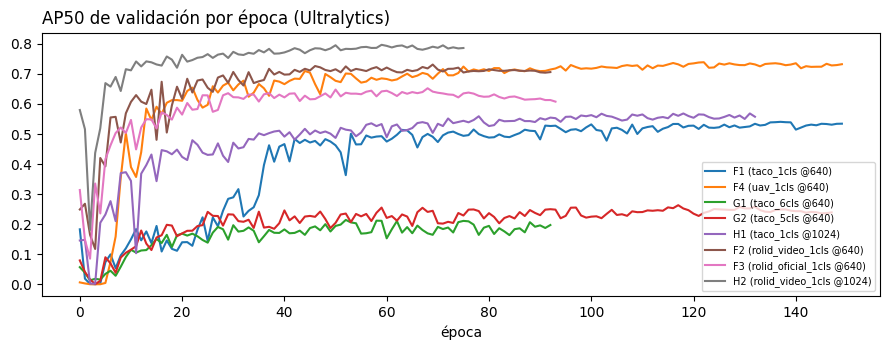

,estado,detalle
exp,,
F1,DONE,val_AP50=0.541 138 min
F4,DONE,val_AP50=0.739 10 min
G1,DONE,val_AP50=0.214 14 min
G2,DONE,val_AP50=0.263 21 min
H1,DONE,val_AP50=0.568 45 min
F2,DONE,val_AP50=0.731 104 min
F3,DONE,val_AP50=0.652 108 min
H2,DONE,val_AP50=0.797 170 min


In [4]:
# ── Curvas y resumen del entrenamiento ───────────────────────────────────────
_hechos = [e for e in PLAN if estado_exp(e) == "DONE"]
if _hechos:
    fig, ax = plt.subplots(figsize=(9, 3.6))
    for e in _hechos:
        m = json.loads((RUNS / e / "DONE.json").read_text())
        va = m["hist"].get("va_ap50", [])
        if va:
            ax.plot(va, label="{} ({} @{})".format(e, m["config"]["gold"],
                                                   m["config"]["imgsz"]))
    ax.set_title("AP50 de validación por época (Ultralytics)", loc="left")
    ax.set_xlabel("época"); ax.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(FIG_DIR / "p1_curvas.png", bbox_inches="tight")
    display(fig); plt.close(fig)
    tablero()
else:
    print("ningún experimento P1 terminado aún")

## Parte 3 · Evaluación unificada contra los GT de gold

Predicciones de cada modelo sobre los test que correspondan, convertidas a COCO y
evaluadas con pycocotools la misma vara que P0. Las predicciones quedan guardadas
(`preds_<dominio>.json`) como insumo del análisis TIDE de la notebook 06.

In [5]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import contextlib, io as _io


def _mejor_peso(exp_id):
    p = RUNS / exp_id / "ultra" / "train" / "weights" / "best.pt"
    return p if p.exists() else None


def evaluar_contra(exp_modelo, exp_gt, split="test", imgsz=None):
    """Predice con el modelo de exp_modelo sobre el split de exp_gt y evalúa.

    Idempotente: si ya existe preds_<gt>_<split>.json (escrito solo al completar
    la inferencia), se reutiliza y se salta la parte cara — un reintento tras un
    crash del driver MPS solo rehace lo pendiente. En PRUEBA_RAPIDA no se lee ni
    escribe caché (las predicciones truncadas envenenarían una corrida completa).
    """
    peso = _mejor_peso(exp_modelo)
    if peso is None:
        return None
    gt_path = GOLD / "coco" / "{}_{}.json".format(exp_gt, split)
    with contextlib.redirect_stdout(_io.StringIO()):
        gt = COCO(str(gt_path))
    imgs = gt.dataset["images"]
    if PRUEBA_RAPIDA:
        imgs = imgs[:8]

    destino = RUNS / exp_modelo / "preds_{}_{}.json".format(exp_gt, split)
    preds = None
    if destino.exists() and not PRUEBA_RAPIDA:
        preds = json.loads(destino.read_text())
        print("  [caché] {} <- {}".format(exp_modelo, destino.name))

    if preds is None:
        rutas = [str(GOLD / i["file_name"]) for i in imgs]
        # el stream de Ultralytics preserva el orden de la lista fuente, pero NO
        # conserva la ruta original (r.path degenera a 'imageN.jpg'): el mapeo a
        # image_id se hace por posicion, no por nombre
        ids_orden = [i["id"] for i in imgs]

        modelo = YOLO(str(peso))
        isz = imgsz or CFG_P1[exp_modelo]["imgsz"]
        # la inferencia @>=1024 en MPS dispara un assert determinista del driver
        # de Metal (dos crashes identicos del kernel, mismo stack en
        # _mps_convolution): esa evaluacion va por CPU; @640 MPS es estable
        dev_eval = "cpu" if (DEVICE == "mps" and isz >= 1024) else DEVICE
        if dev_eval != DEVICE:
            print("  [cpu] {} @{} sobre {} ({} imgs) — evita el assert de Metal".format(
                exp_modelo, isz, exp_gt, len(rutas)))
        preds = []
        for k, r in enumerate(modelo.predict(source=rutas, imgsz=isz, conf=0.001,
                                             max_det=300, device=dev_eval,
                                             stream=True, verbose=False)):
            iid = ids_orden[k]
            for caja, punt, lab in zip(r.boxes.xyxy.cpu().numpy(),
                                       r.boxes.conf.cpu().numpy(),
                                       r.boxes.cls.cpu().numpy()):
                x1, y1, x2, y2 = caja.tolist()
                preds.append({"image_id": iid, "category_id": int(lab) + 1,
                              "bbox": [x1, y1, x2 - x1, y2 - y1], "score": float(punt)})
        if not PRUEBA_RAPIDA:
            destino.write_text(json.dumps(preds))
        del modelo
        gc.collect()
        if DEVICE == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

    if not preds:
        return {"ap50": 0.0, "ap": 0.0, "ap_s": 0.0, "ap_m": 0.0, "ap_l": 0.0,
                "por_clase_ap50": {}}
    with contextlib.redirect_stdout(_io.StringIO()):
        dt = gt.loadRes(preds)
        ev = COCOeval(gt, dt, "bbox")
        if PRUEBA_RAPIDA:
            ev.params.imgIds = [i["id"] for i in imgs]
        ev.evaluate(); ev.accumulate(); ev.summarize()
    s = ev.stats
    prec = ev.eval["precision"]          # [T, R, K, A, M]
    por_clase = {}
    for k, cid in enumerate(ev.params.catIds):
        pr = prec[0, :, k, 0, -1]
        pr = pr[pr > -1]
        # pycocotools.loadCats devuelve None si el id no es int nativo (numpy)
        por_clase[gt.loadCats(int(cid))[0]["name"]] = float(pr.mean()) if pr.size else None
    return {"ap50": float(s[1]), "ap": float(s[0]), "ap_s": float(s[3]),
            "ap_m": float(s[4]), "ap_l": float(s[5]), "por_clase_ap50": por_clase}


print("evaluador cargado")

evaluador cargado


  [caché] F1 <- preds_taco_1cls_test.json
  taco -> taco: AP50 0.442 · AP 0.318 · AP_s 0.056
  [caché] F1 <- preds_rolid_video_1cls_test.json
  taco -> rolid: AP50 0.002 · AP 0.001 · AP_s 0.001
  [caché] F1 <- preds_uav_1cls_test.json
  taco -> uav: AP50 0.527 · AP 0.284 · AP_s 0.189
  [caché] F2 <- preds_taco_1cls_test.json
  rolid -> taco: AP50 0.001 · AP 0.000 · AP_s 0.000
  [caché] F2 <- preds_rolid_video_1cls_test.json
  rolid -> rolid: AP50 0.695 · AP 0.279 · AP_s 0.279
  [caché] F2 <- preds_uav_1cls_test.json
  rolid -> uav: AP50 0.064 · AP 0.025 · AP_s 0.014
  [caché] F4 <- preds_taco_1cls_test.json
  uav -> taco: AP50 0.106 · AP 0.062 · AP_s 0.027
  [caché] F4 <- preds_rolid_video_1cls_test.json
  uav -> rolid: AP50 0.006 · AP 0.002 · AP_s 0.003
  [caché] F4 <- preds_uav_1cls_test.json
  uav -> uav: AP50 0.779 · AP 0.457 · AP_s 0.374


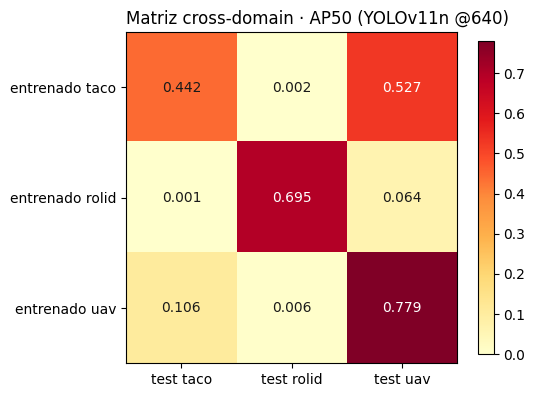


AP50 medio in-domain: 0.639 · cross-domain: 0.118 · degradación: 82%


In [6]:
# ── Matriz cross-domain 3x3 (el resultado principal) ─────────────────────────
MODELOS_MATRIZ = {"taco": "F1", "rolid": "F2", "uav": "F4"}
GT_MATRIZ = {"taco": "taco_1cls", "rolid": "rolid_video_1cls", "uav": "uav_1cls"}

listos = all(estado_exp(e) == "DONE" for e in MODELOS_MATRIZ.values())
if not listos:
    print("[omitido] la matriz requiere F1, F2 y F4 terminados")
else:
    M50 = pd.DataFrame(index=MODELOS_MATRIZ, columns=GT_MATRIZ, dtype=float)
    detalle = {}
    for dom_m, exp_m in MODELOS_MATRIZ.items():
        for dom_g, exp_g in GT_MATRIZ.items():
            r = evaluar_contra(exp_m, exp_g)
            M50.loc[dom_m, dom_g] = r["ap50"]
            detalle["{}->{}".format(dom_m, dom_g)] = r
            print("  {} -> {}: AP50 {:.3f} · AP {:.3f} · AP_s {:.3f}".format(
                dom_m, dom_g, r["ap50"], r["ap"], r["ap_s"]))
    (RUNS / "matriz_cross_domain.json").write_text(
        json.dumps(detalle, indent=2, default=float))

    fig, ax = plt.subplots(figsize=(5.6, 4.6))
    im = ax.imshow(M50.values.astype(float), cmap="YlOrRd", vmin=0)
    ax.set_xticks(range(3)); ax.set_xticklabels(["test " + c for c in M50.columns])
    ax.set_yticks(range(3)); ax.set_yticklabels(["entrenado " + i for i in M50.index])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, "{:.3f}".format(M50.values[i, j]), ha="center", va="center",
                    fontsize=10,
                    color="white" if M50.values[i, j] > M50.values.max() * 0.6 else "#1a1a19")
    ax.set_title("Matriz cross-domain · AP50 (YOLOv11n @640)", loc="left")
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout(); fig.savefig(FIG_DIR / "p1_matriz_cross_domain.png",
                                    bbox_inches="tight", dpi=160)
    display(fig); plt.close(fig)

    diag = np.diag(M50.values.astype(float))
    fuera = M50.values.astype(float)[~np.eye(3, dtype=bool)]
    print("\nAP50 medio in-domain: {:.3f} · cross-domain: {:.3f} · degradación: {:.0f}%".format(
        diag.mean(), fuera.mean(), (1 - fuera.mean() / max(diag.mean(), 1e-9)) * 100))

In [7]:
# ── Oficial vs por-video: cuantificar la inflación por fuga (H4) ─────────────
if estado_exp("F2") == "DONE" and estado_exp("F3") == "DONE":
    r_video = evaluar_contra("F2", "rolid_video_1cls")
    r_ofic = evaluar_contra("F3", "rolid_oficial_1cls")
    r_cruz = evaluar_contra("F3", "rolid_video_1cls")   # el modelo 'inflado' sin su fuga
    filas = [
        {"esquema": "oficial (58% fuga)", "modelo": "F3", "test": "oficial",
         "AP50": r_ofic["ap50"], "AP": r_ofic["ap"]},
        {"esquema": "por video (0% fuga)", "modelo": "F2", "test": "video",
         "AP50": r_video["ap50"], "AP": r_video["ap"]},
        {"esquema": "F3 evaluado sin fuga", "modelo": "F3", "test": "video",
         "AP50": r_cruz["ap50"], "AP": r_cruz["ap"]},
    ]
    df = pd.DataFrame(filas).set_index("esquema").round(4)
    display(df)
    infl = (r_ofic["ap50"] - r_video["ap50"]) / max(r_video["ap50"], 1e-9) * 100
    print("inflación aparente del esquema oficial sobre el honesto: {:+.1f}% en AP50".format(infl))
    (RUNS / "oficial_vs_video.json").write_text(df.to_json(orient="index"))
else:
    print("[omitido] requiere F2 y F3 terminados")

  [caché] F2 <- preds_rolid_video_1cls_test.json
  [caché] F3 <- preds_rolid_oficial_1cls_test.json
  [caché] F3 <- preds_rolid_video_1cls_test.json


,modelo,test,AP50,AP
esquema,,,,
oficial (58% fuga),F3,oficial,0.6201,0.2297
por video (0% fuga),F2,video,0.6954,0.2788
F3 evaluado sin fuga,F3,video,0.8439,0.3716


inflación aparente del esquema oficial sobre el honesto: -10.8% en AP50


In [8]:
# ── Ablación de resolución (objetos small) ───────────────────────────────────
pares = [("F1", "H1", "taco_1cls"), ("F2", "H2", "rolid_video_1cls")]
filas = []
for e640, e1024, gtx in pares:
    if estado_exp(e640) == "DONE" and estado_exp(e1024) == "DONE":
        r6 = evaluar_contra(e640, gtx)
        r10 = evaluar_contra(e1024, gtx)
        filas.append({"dataset": gtx.split("_")[0], "AP50@640": r6["ap50"],
                      "AP50@1024": r10["ap50"], "AP_s@640": r6["ap_s"],
                      "AP_s@1024": r10["ap_s"],
                      "ganancia_AP_s": r10["ap_s"] - r6["ap_s"]})
if filas:
    df = pd.DataFrame(filas).set_index("dataset").round(4)
    display(df)
    (RUNS / "ablacion_resolucion.json").write_text(df.to_json(orient="index"))
else:
    print("[omitido] requiere los pares F1/H1 o F2/H2 terminados")

  [caché] F1 <- preds_taco_1cls_test.json
  [cpu] H1 @1024 sobre taco_1cls (270 imgs) — evita el assert de Metal
  [caché] F2 <- preds_rolid_video_1cls_test.json
  [caché] H2 <- preds_rolid_video_1cls_test.json


,AP50@640,AP50@1024,AP_s@640,AP_s@1024,ganancia_AP_s
dataset,,,,,
taco,0.4418,0.4735,0.0563,0.0957,0.0394
rolid,0.6954,0.7787,0.2789,0.3371,0.0582


In [9]:
# ── Comparativa A/B: 6 clases (con vidrio) contra 5 ──────────────────────────
if estado_exp("G1") == "DONE" and estado_exp("G2") == "DONE":
    rA = evaluar_contra("G1", "taco_6cls")
    rB = evaluar_contra("G2", "taco_5cls")
    clases = sorted(set(list(rA["por_clase_ap50"]) + list(rB["por_clase_ap50"])))
    df = pd.DataFrame({
        "A_6cls": {c: rA["por_clase_ap50"].get(c) for c in clases},
        "B_5cls": {c: rB["por_clase_ap50"].get(c) for c in clases},
    }).round(4)
    df.loc["_global"] = [rA["ap50"], rB["ap50"]]
    display(df)
    (RUNS / "variantes_ab.json").write_text(df.to_json(orient="index"))
    comunes = [c for c in clases if c != "vidrio" and df.loc[c].notna().all()]
    if comunes:
        dif = (df.loc[comunes, "B_5cls"] - df.loc[comunes, "A_6cls"]).mean()
        print("efecto de excluir vidrio sobre las 5 clases comunes: {:+.4f} AP50 medio".format(dif))
else:
    print("[omitido] requiere G1 y G2 terminados")

  [caché] G1 <- preds_taco_6cls_test.json
  [caché] G2 <- preds_taco_5cls_test.json


,A_6cls,B_5cls
cigarrillo,0.07620,0.081400
metal,0.17400,0.250900
papel_carton,0.17490,0.198700
plastico_flexible,0.22140,0.222100
plastico_rigido,0.24440,0.207800
vidrio,0.04860,NaN
_global,0.15659,0.192178


efecto de excluir vidrio sobre las 5 clases comunes: +0.0140 AP50 medio


## Parte 4 · Consolidación

In [10]:
print("═" * 96)
print("CONSOLIDACIÓN P1")
print("═" * 96)
tablero()

consolidado = {}
for e in PLAN:
    if estado_exp(e) == "DONE":
        m = json.loads((RUNS / e / "DONE.json").read_text())
        consolidado[e] = {"config": m.get("config", {}), "mejor": m.get("mejor", {}),
                          "epocas_efectivas": m.get("epocas_efectivas"),
                          "tiempo_min": round(m.get("tiempo_s", 0) / 60, 1)}
extras = {}
for nombre in ("matriz_cross_domain", "oficial_vs_video",
               "ablacion_resolucion", "variantes_ab"):
    p = RUNS / (nombre + ".json")
    if p.exists():
        extras[nombre] = json.loads(p.read_text())
(RUNS / "consolidado_p1.json").write_text(
    json.dumps({"generado": datetime.datetime.now().isoformat(timespec="seconds"),
                "perfil": PERFIL, "experimentos": consolidado, "analisis": extras},
               indent=2, ensure_ascii=False, default=float))
print("\nresumen -> {}".format(RUNS / "consolidado_p1.json"))
print("terminados: {}/{} · fallidos: {} · pendientes: {}".format(
    sum(1 for e in PLAN if estado_exp(e) == "DONE"), len(PLAN),
    [e for e in PLAN if estado_exp(e) == "FAILED"] or "ninguno",
    [e for e in PLAN if estado_exp(e) in ("PENDING", "PARCIAL")] or "ninguno"))

if _caf and _caf.poll() is None:
    _caf.terminate()
    print("caffeinate detenido")

════════════════════════════════════════════════════════════════════════════════════════════════
CONSOLIDACIÓN P1
════════════════════════════════════════════════════════════════════════════════════════════════


,estado,detalle
exp,,
F1,DONE,val_AP50=0.541 138 min
F4,DONE,val_AP50=0.739 10 min
G1,DONE,val_AP50=0.214 14 min
G2,DONE,val_AP50=0.263 21 min
H1,DONE,val_AP50=0.568 45 min
F2,DONE,val_AP50=0.731 104 min
F3,DONE,val_AP50=0.652 108 min
H2,DONE,val_AP50=0.797 170 min



resumen -> /Volumes/JS-MAIN/Personal/Education/UNI/AI Master/Semesters & Class/Semester 3/Computer Vision/final-project/code/experiments/p1/consolidado_p1.json
terminados: 8/8 · fallidos: ninguno · pendientes: ninguno
caffeinate detenido


## Notas de operación

- **Run All siempre**: DONE se salta, FAILED se reintenta, PARCIAL reanuda desde `last.pt`.
- **Orden barato → caro**: F1, F4, G1, G2, H1 caben en una noche; F2, F3 en la segunda;
  H2 es el largo (~8–12 h) — si su proyección supera el presupuesto, el guardián lo manda
  a Colab con el mensaje correspondiente.
- **Carril Colab para P1** (opcional): requiere `gold_colab_p1.zip` (generado por la 03 con
  `PAQUETE_COLAB_P1 = True`) en `MyDrive/`; los runs van a `MyDrive/waste_p1_runs/`.
- Las celdas de análisis (matriz, fuga, resolución, A/B) se saltan con aviso mientras
  falten sus modelos, y se completan solas al reejecutar cuando estén.
- Los `preds_*.json` de cada modelo quedan para el análisis TIDE de la notebook 06.